# Exploration des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_clinical = pd.read_csv('X_train/clinical_train.csv')
df_clinical.head()

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx"
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"


In [2]:
# Print type of each column
df_clinical = df_clinical.apply(lambda x: x.str.lower().str.strip() if isinstance(x, str) else x)
print(df_clinical.dtypes)

ID               object
CENTER           object
BM_BLAST        float64
WBC             float64
ANC             float64
MONOCYTES       float64
HB              float64
PLT             float64
CYTOGENETICS     object
dtype: object


In [3]:
df_clinical.head()
# Check for missing values
print(df_clinical.isnull().sum())
# Count unique values in each column
print(df_clinical.nunique())

ID                0
CENTER            0
BM_BLAST        109
WBC             272
ANC             193
MONOCYTES       601
HB              110
PLT             124
CYTOGENETICS    387
dtype: int64
ID              3323
CENTER            23
BM_BLAST         139
WBC              699
ANC             1026
MONOCYTES        609
HB               239
PLT              586
CYTOGENETICS    1194
dtype: int64


In [4]:
print(df_clinical.describe())

          BM_BLAST          WBC          ANC    MONOCYTES           HB  \
count  3214.000000  3051.000000  3130.000000  2722.000000  3213.000000   
mean      5.982545     6.535164     3.264735     0.955868     9.893549   
std       7.615439    10.247219     5.237043     2.666478     2.041158   
min       0.000000     0.200000     0.000000     0.000000     4.000000   
25%       1.000000     2.700000     1.000000     0.150000     8.500000   
50%       3.000000     4.100000     2.000000     0.370000     9.700000   
75%       8.000000     6.655000     3.690000     0.783000    11.200000   
max      91.000000   154.400000   109.620000    44.200000    16.600000   

               PLT  
count  3199.000000  
mean    167.048900  
std     149.477031  
min       2.000000  
25%      65.500000  
50%     123.000000  
75%     229.500000  
max    1451.000000  


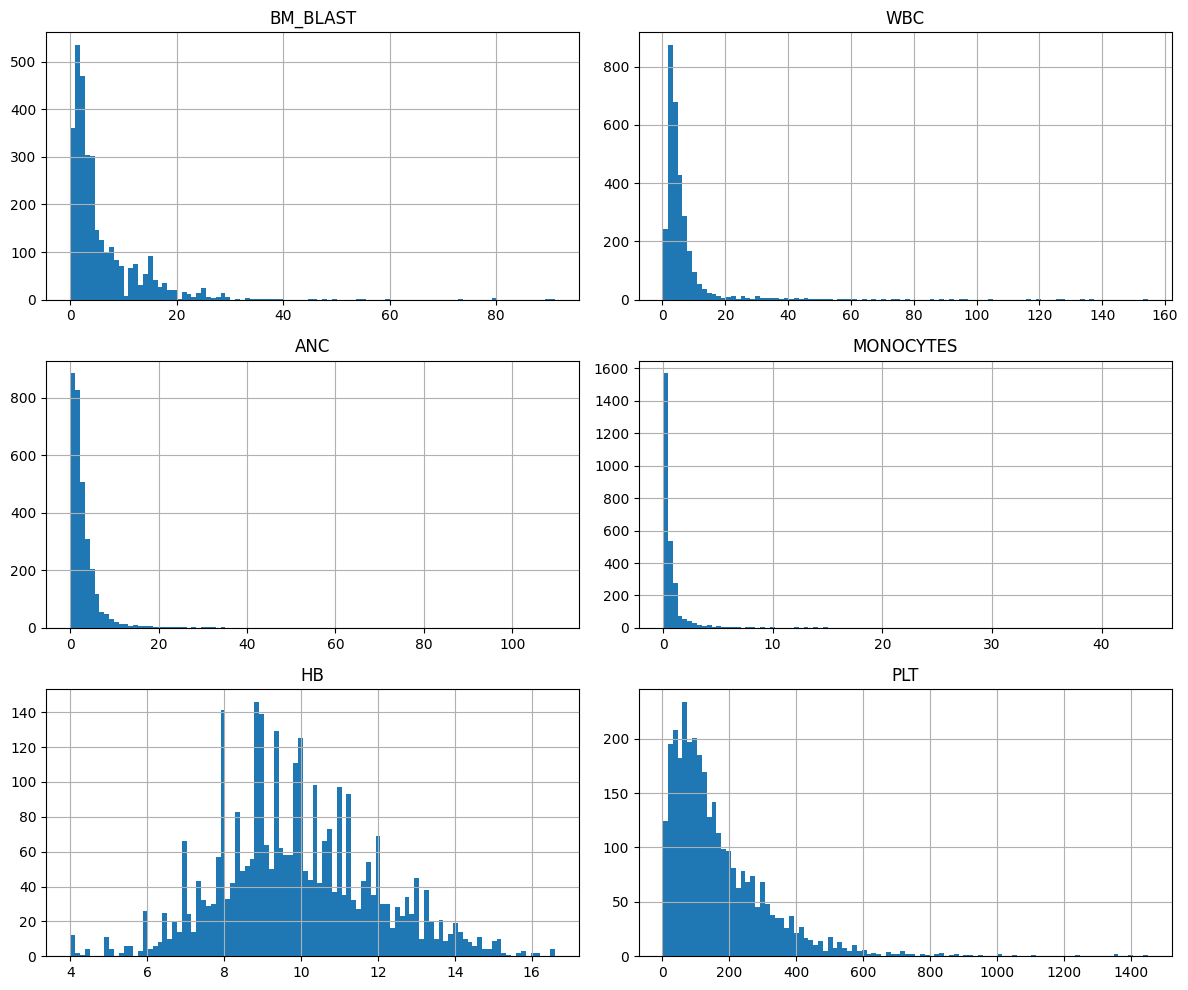

In [5]:
# Plot histograms for each column
df_clinical.hist(figsize=(12, 10), bins=100)
plt.tight_layout()
plt.show()

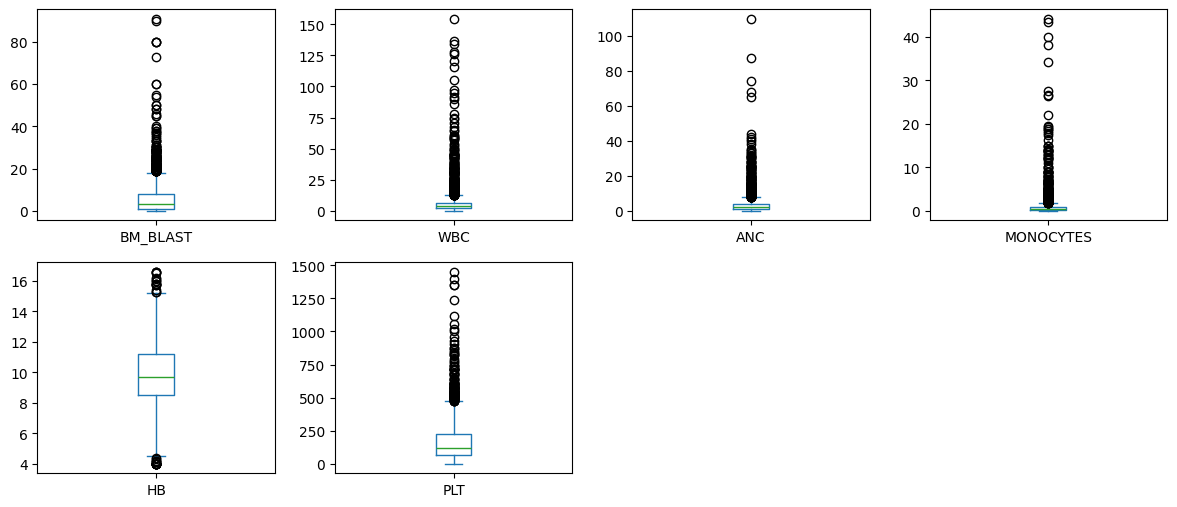

In [6]:
# Plot boxplots for each column
df_clinical.plot(kind='box', subplots=True, layout=(4, 4), figsize=(12, 10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

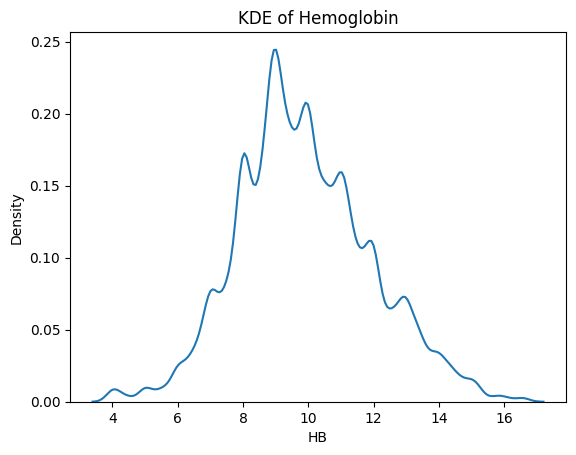

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df_clinical, x='HB', bw_adjust=0.5)  # lower = sharper, higher = smoother
plt.title("KDE of Hemoglobin")
plt.show()

IndexError: index 6 is out of bounds for axis 0 with size 6

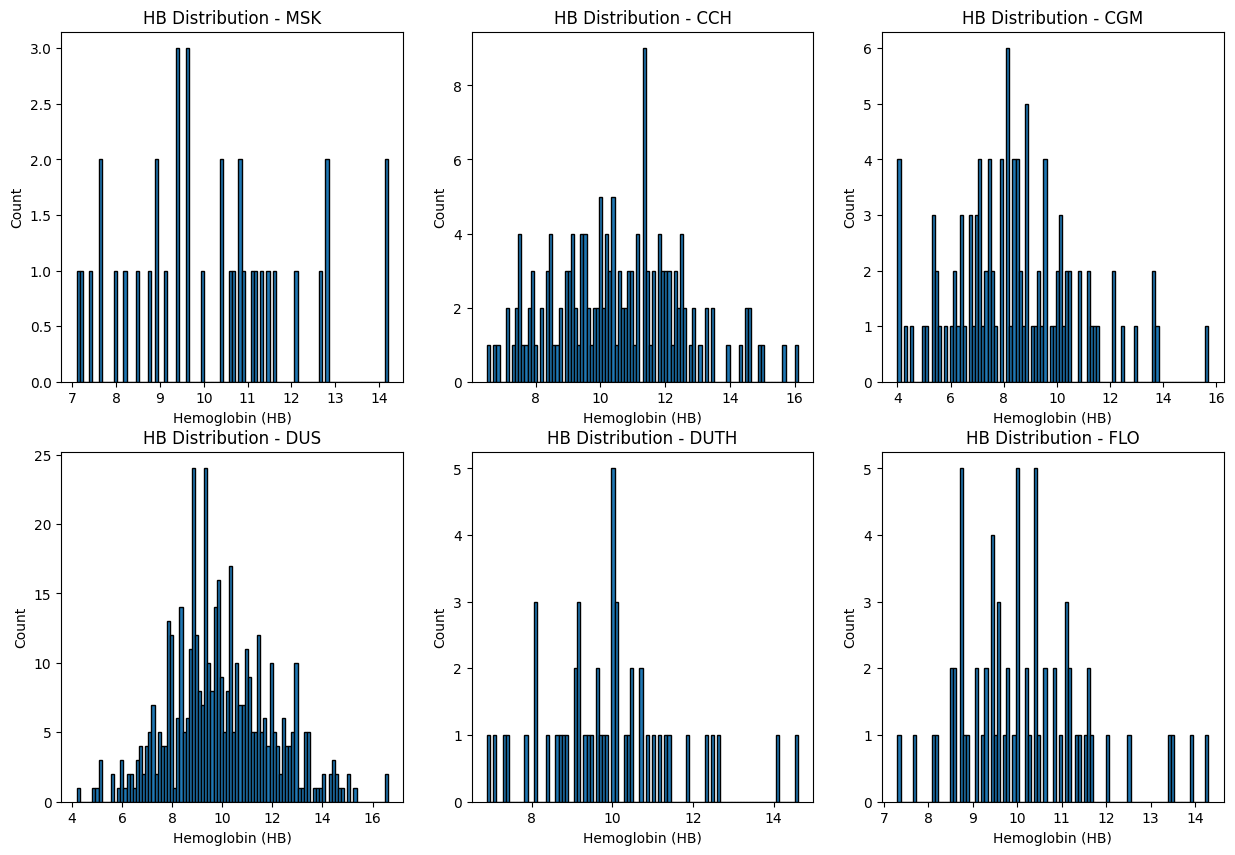

In [8]:
# Create a figure with subplots for each center
centers = df_clinical['CENTER'].unique()
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, center in enumerate(centers):
    center_data = df_clinical[df_clinical['CENTER'] == center]['HB']
    axes[idx].hist(center_data, bins=100, edgecolor='black')
    axes[idx].set_title(f'HB Distribution - {center}')
    axes[idx].set_xlabel('Hemoglobin (HB)')
    axes[idx].set_ylabel('Count')

plt.tight_layout()
plt.show()

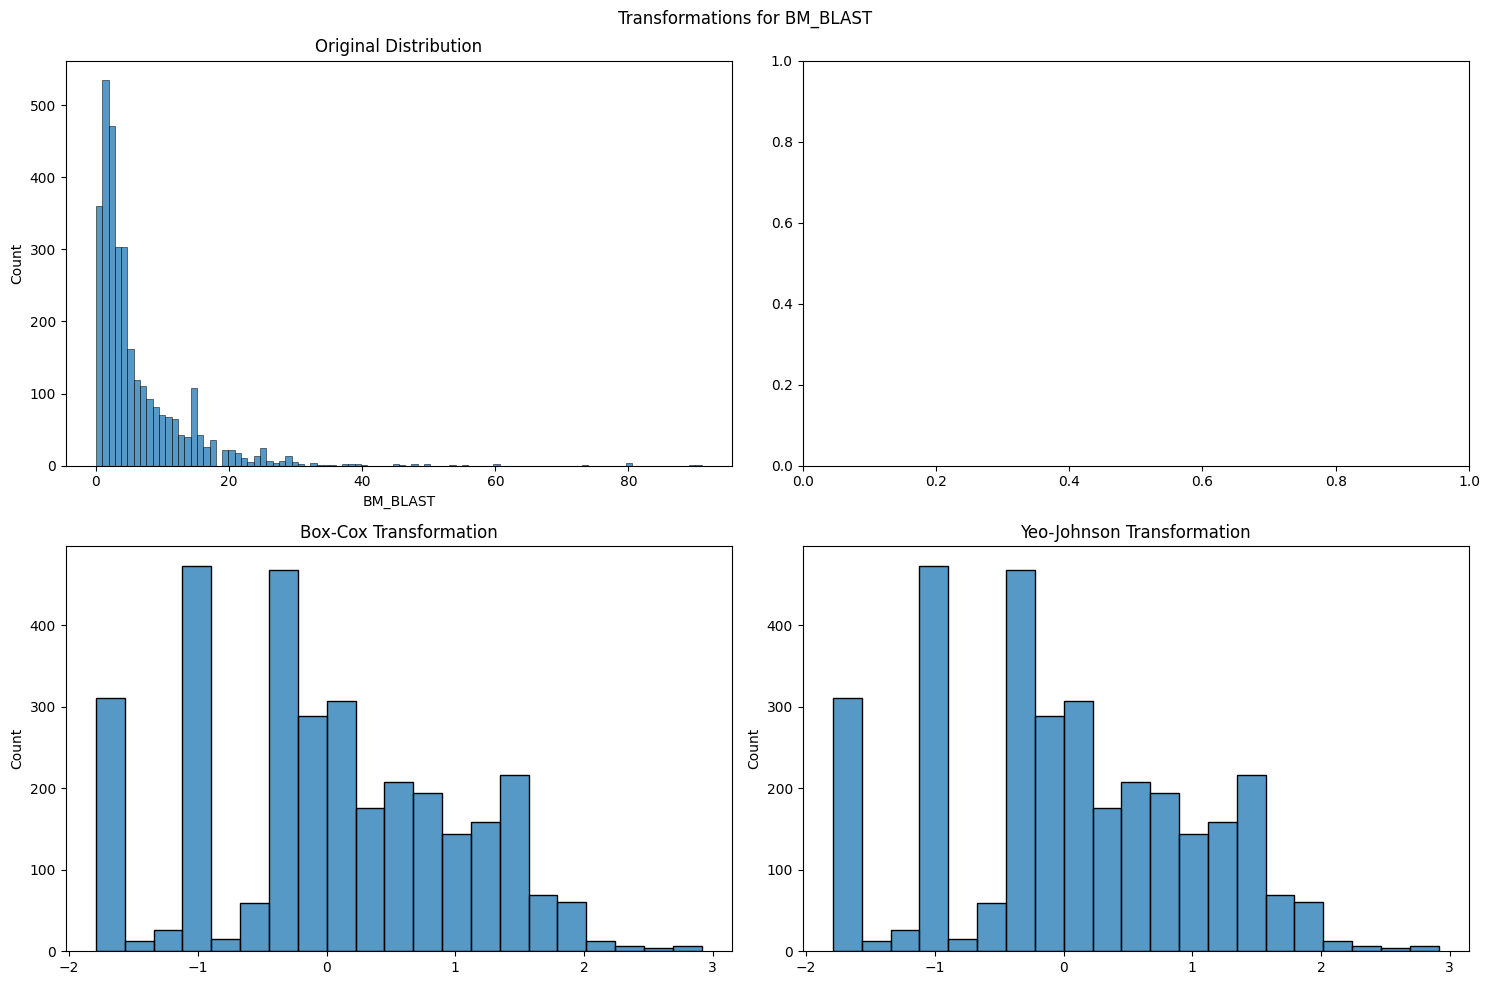


Skewness for BM_BLAST:
Original: 3.625
Box-Cox: 0.020
Yeo-Johnson: 0.020


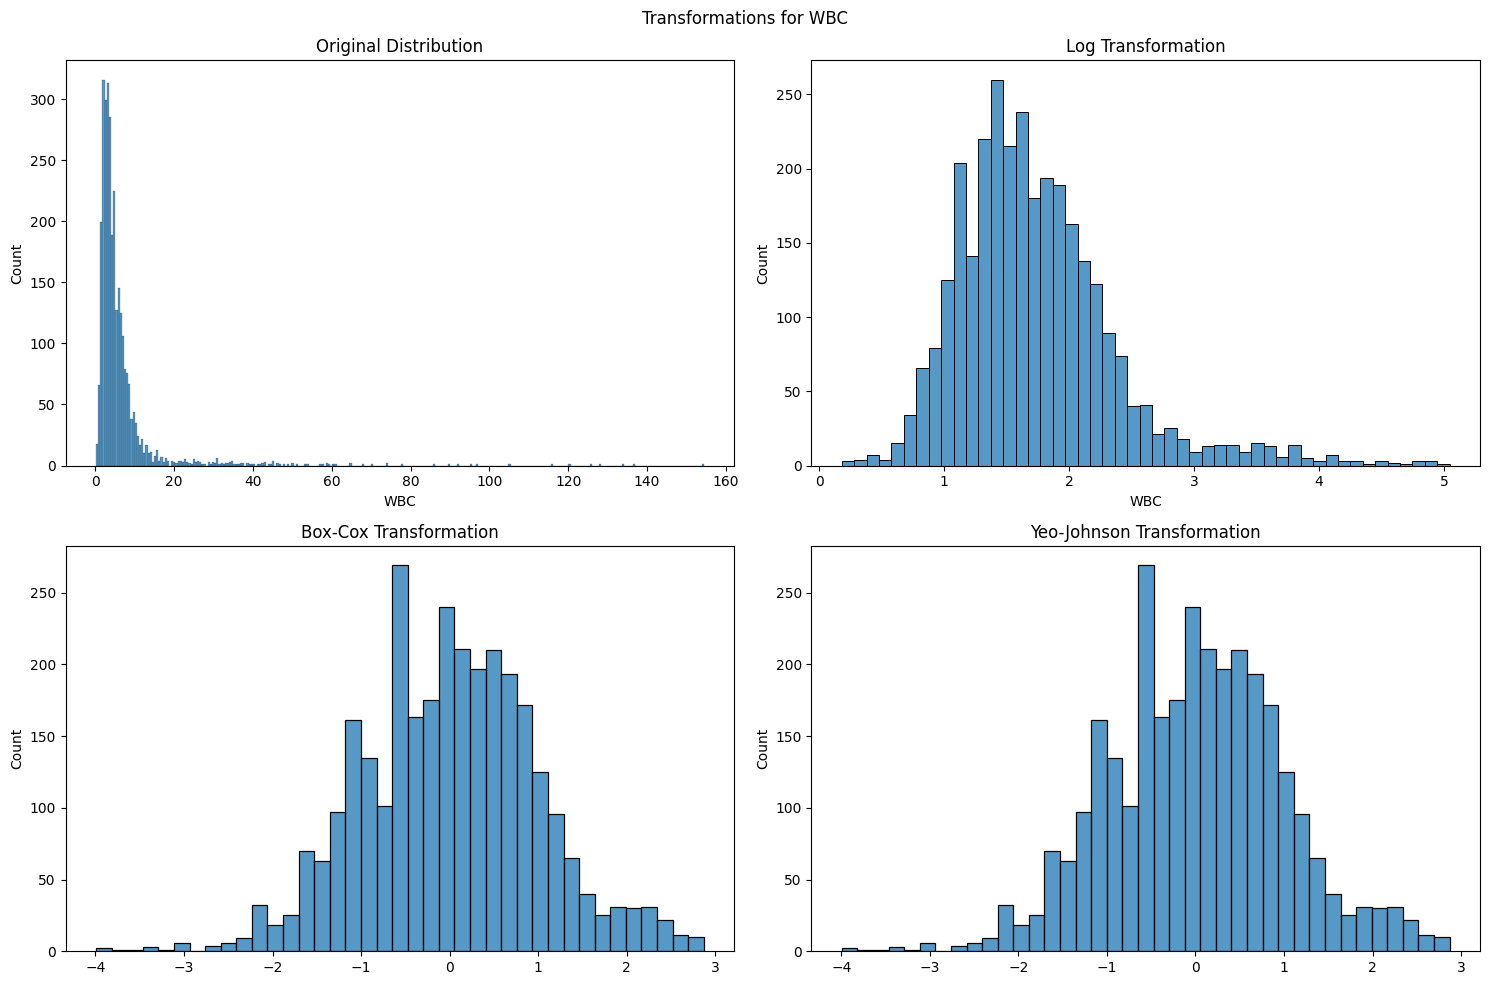


Skewness for WBC:
Original: 7.093
Box-Cox: -0.015
Yeo-Johnson: -0.015


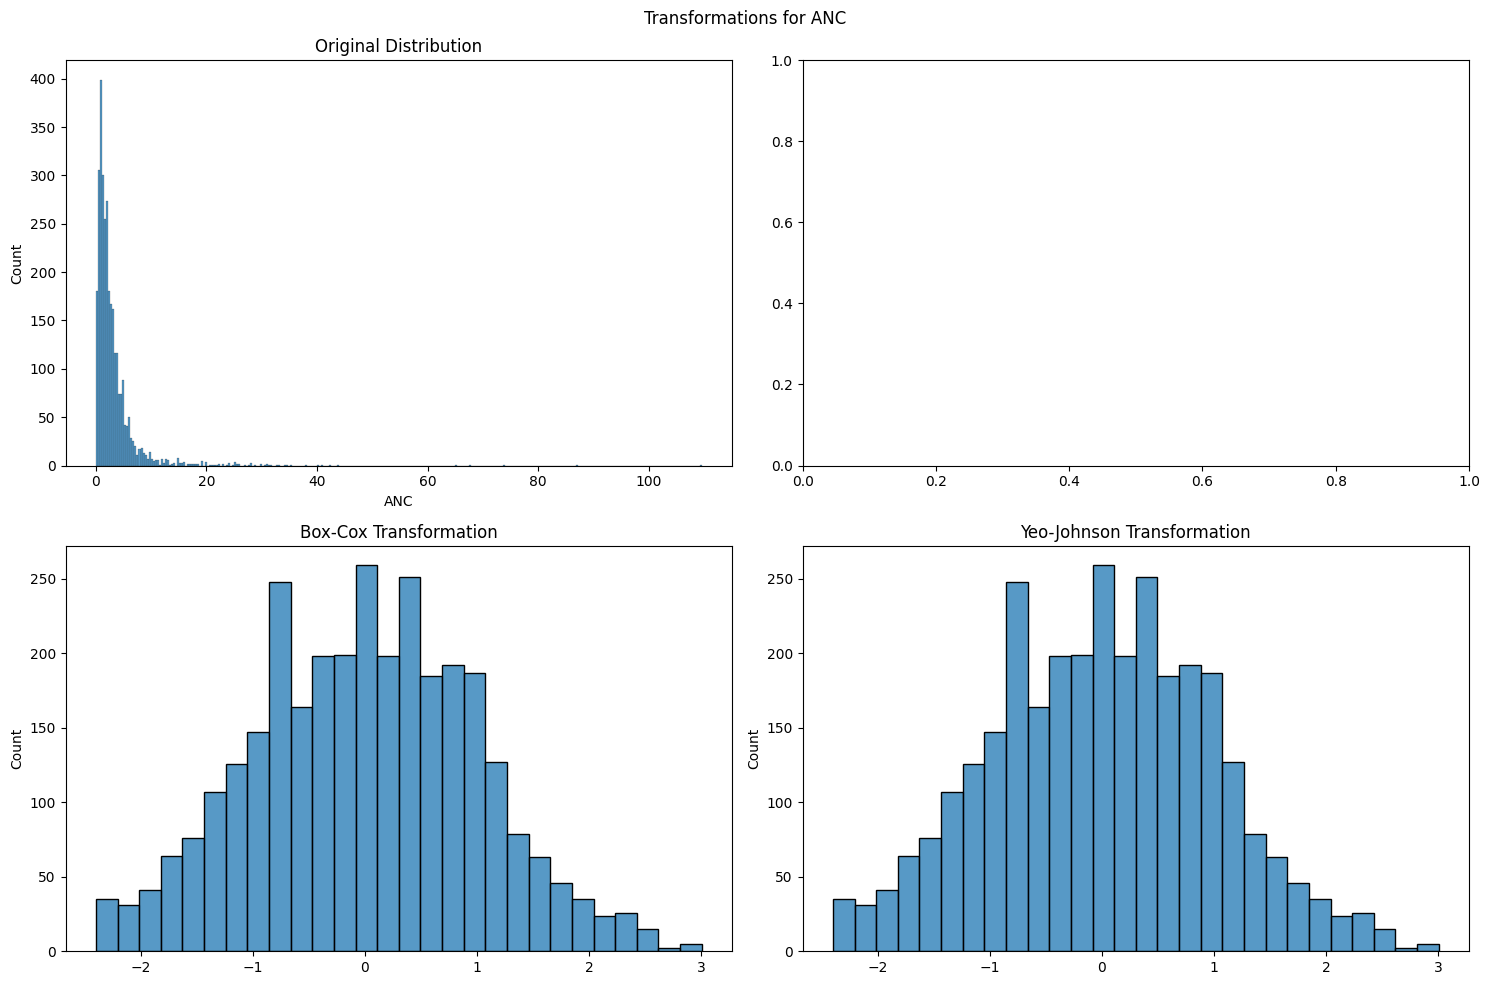


Skewness for ANC:
Original: 8.068
Box-Cox: 0.032
Yeo-Johnson: 0.032


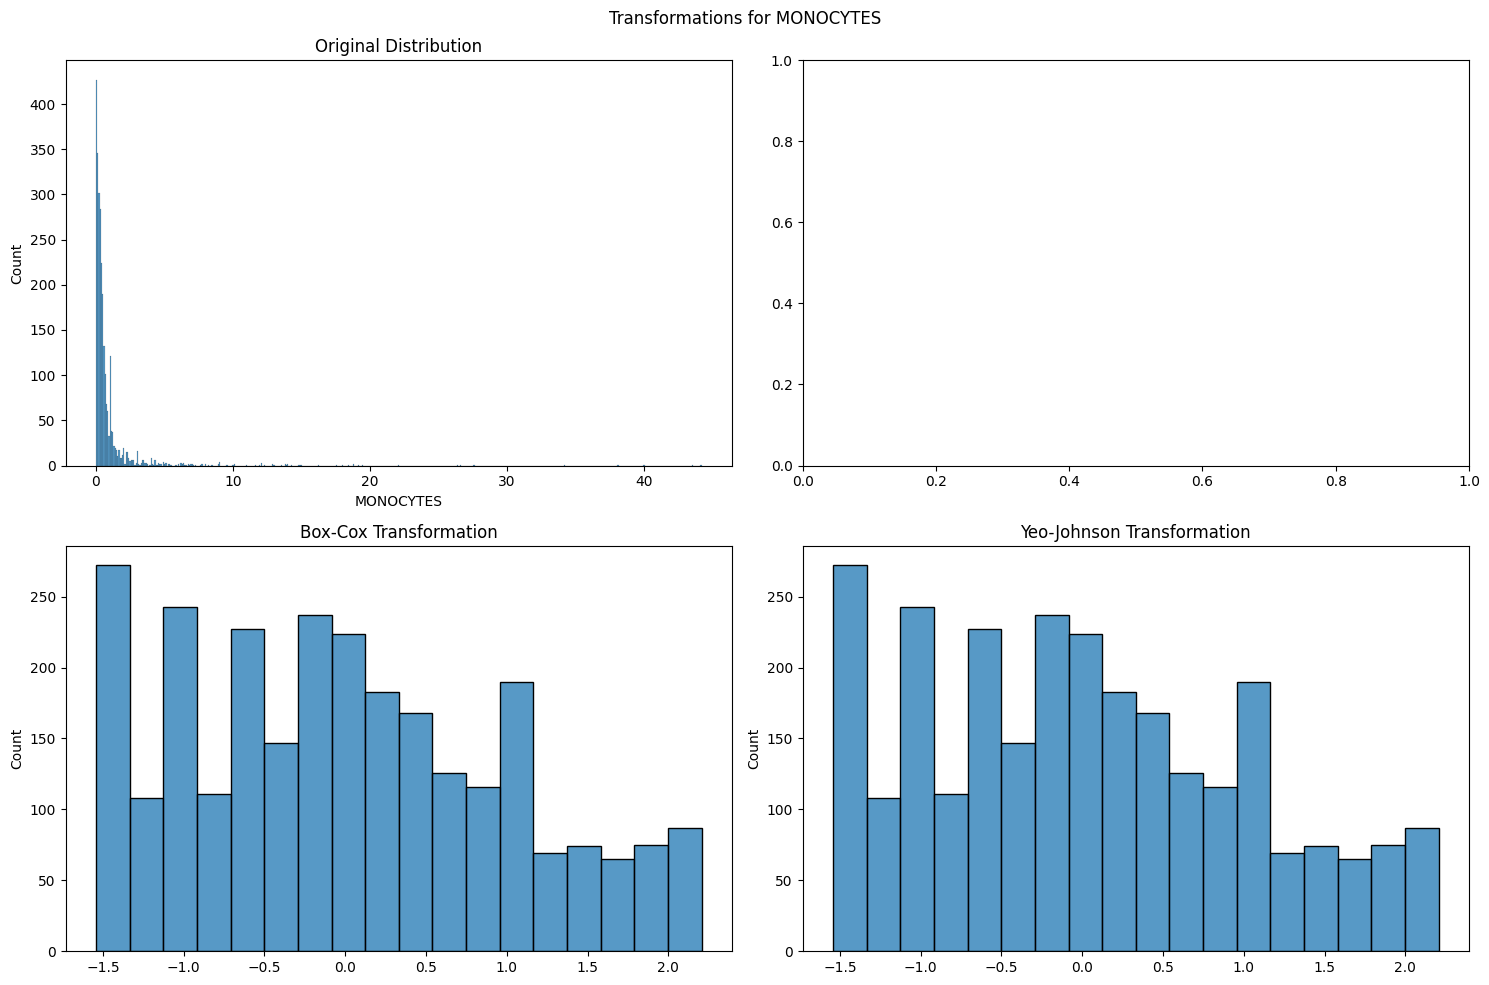


Skewness for MONOCYTES:
Original: 8.939
Box-Cox: 0.307
Yeo-Johnson: 0.307


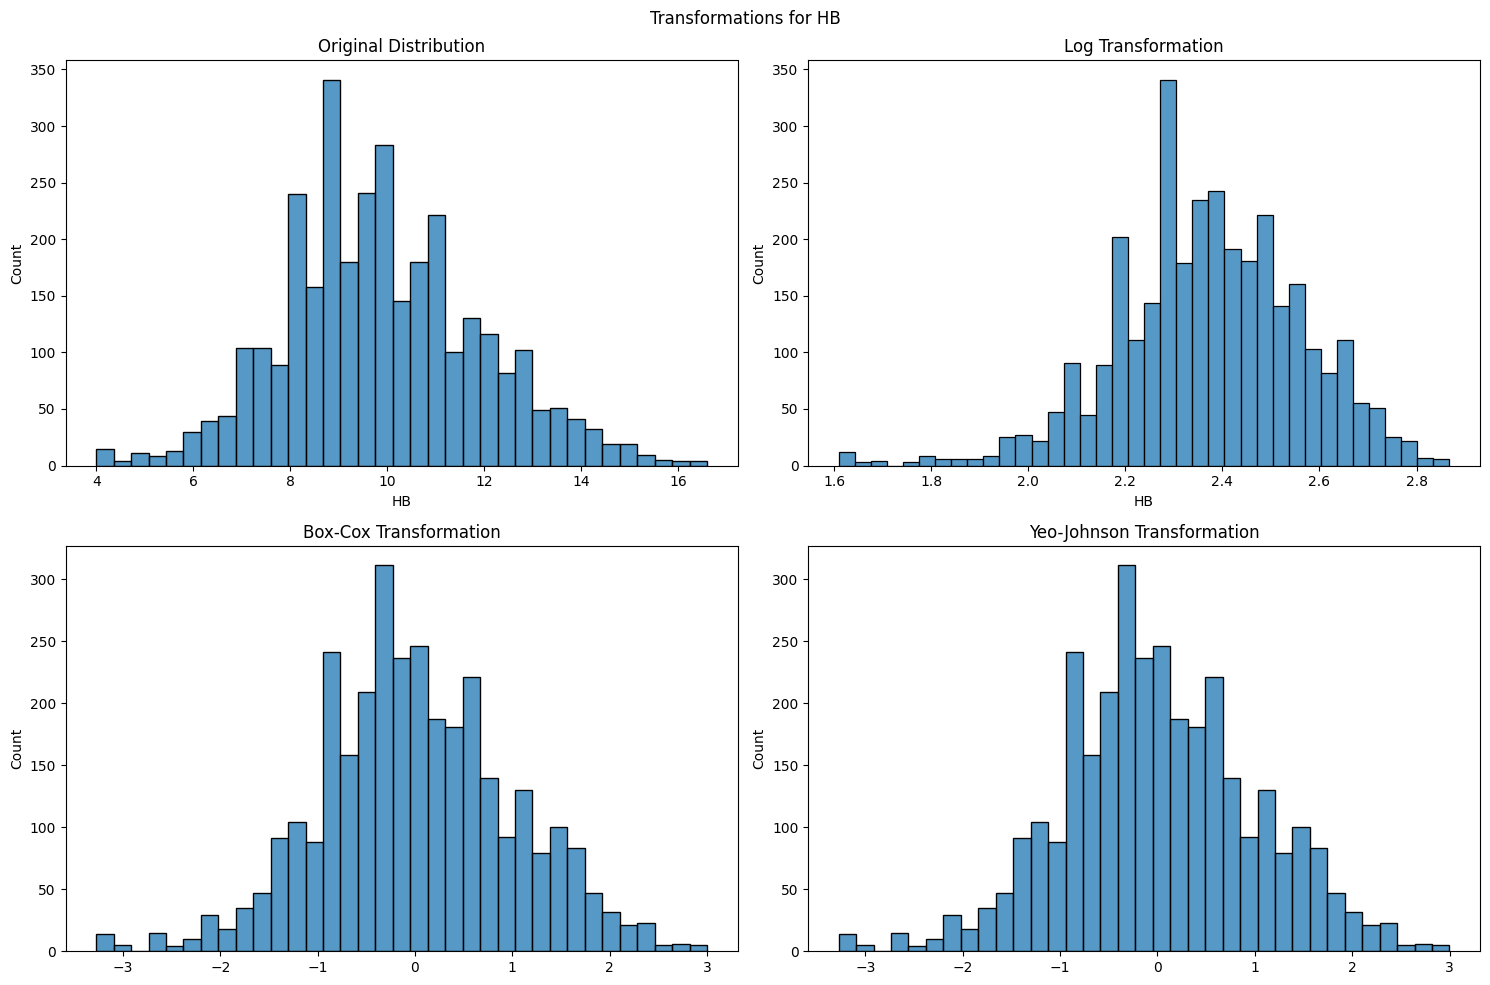


Skewness for HB:
Original: 0.252
Box-Cox: 0.009
Yeo-Johnson: 0.009


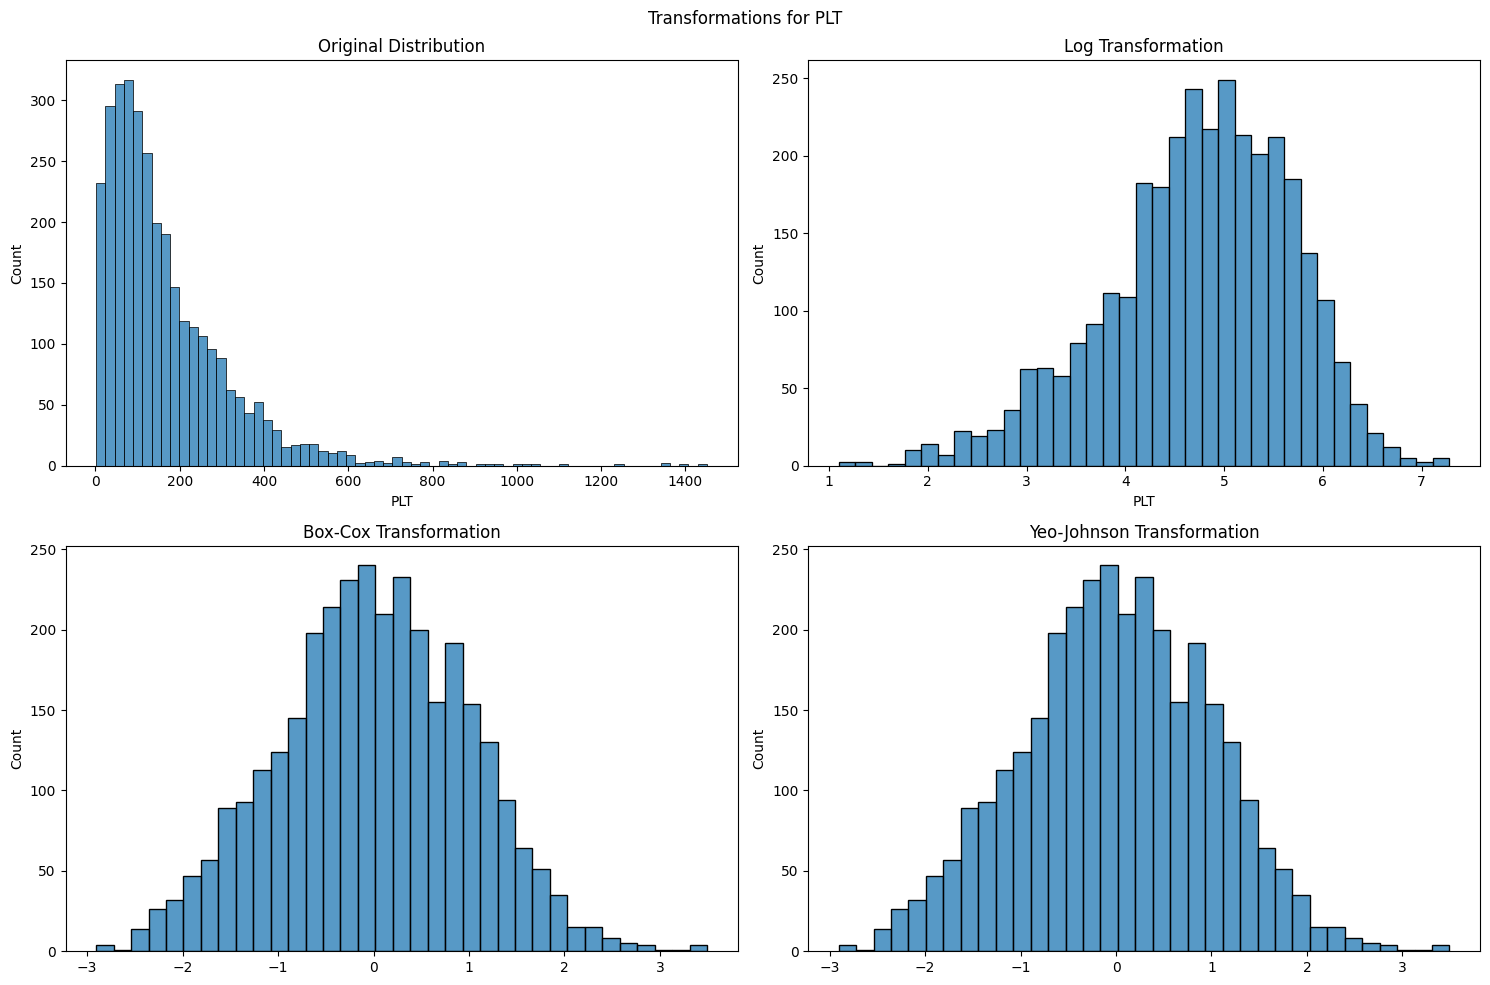


Skewness for PLT:
Original: 2.321
Box-Cox: -0.014
Yeo-Johnson: -0.014


In [9]:
import numpy as np
from sklearn.preprocessing import PowerTransformer, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure for comparing distributions
def plot_transformations(original_data, transformations, title):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.ravel()
    
    # Original distribution
    sns.histplot(data=original_data, ax=axes[0])
    axes[0].set_title('Original Distribution')
    
    # Log transformation
    if min(original_data) > 0:  # Only if data is positive
        sns.histplot(data=np.log1p(original_data), ax=axes[1])
        axes[1].set_title('Log Transformation')
    
    # Box-Cox transformation
    sns.histplot(data=transformations['boxcox'], ax=axes[2])
    axes[2].set_title('Box-Cox Transformation')
    
    # Yeo-Johnson transformation
    sns.histplot(data=transformations['yeojohnson'], ax=axes[3])
    axes[3].set_title('Yeo-Johnson Transformation')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Select numerical columns
numeric_cols = df_clinical.select_dtypes(include=[np.number]).columns

# Apply transformations for each numerical column
for col in numeric_cols:
    # Skip if column has negative values or zeros for log transform
    data = df_clinical[col].values.reshape(-1, 1)
    
    # Initialize transformers
    pt_boxcox = PowerTransformer(method='box-cox')
    pt_yeojohnson = PowerTransformer(method='yeo-johnson')
    
    # Apply transformations
    transformations = {
        'boxcox': pt_boxcox.fit_transform(data + 1).ravel(),  # Adding 1 to handle zeros
        'yeojohnson': pt_yeojohnson.fit_transform(data).ravel()
    }
    
    # Plot distributions
    plot_transformations(df_clinical[col], transformations, f'Transformations for {col}')
    
    # Print skewness before and after transformations
    print(f"\nSkewness for {col}:")
    print(f"Original: {df_clinical[col].skew():.3f}")
    print(f"Box-Cox: {pd.Series(transformations['boxcox']).skew():.3f}")
    print(f"Yeo-Johnson: {pd.Series(transformations['yeojohnson']).skew():.3f}")